In [83]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

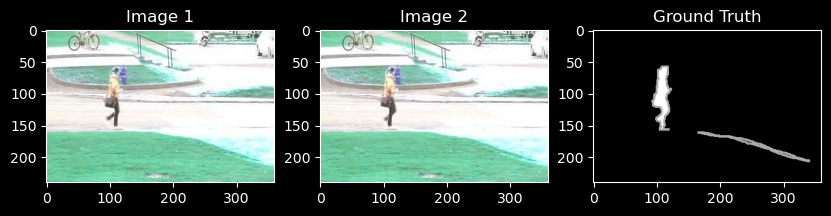

In [84]:
pedestrain_dir = "data/pedestrian"
pedestrinan_input_dir = pedestrain_dir + "/input"
pedestrian_ground_truth_dir = pedestrain_dir + "/groundtruth"

idx = 350

def load_2_images(path, from_idx=1, skip=1):
    idx_6_digits = str(from_idx).zfill(6)
    idx_6_digits_skip = str(from_idx + skip).zfill(6)
    img1 = cv2.imread(f"{path}/in{idx_6_digits}.jpg")
    img2 = cv2.imread(f"{path}/in{idx_6_digits_skip}.jpg")
    ground_truth = cv2.imread(f"{pedestrian_ground_truth_dir}/gt{idx_6_digits_skip}.png")
    return img1, img2, ground_truth

img1, img2, ground_truth = load_2_images(pedestrinan_input_dir, from_idx=idx, skip=1)

f, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(img1)
ax[0].set_title("Image 1")
ax[1].imshow(img2)
ax[1].set_title("Image 2")
ax[2].imshow(ground_truth)
ax[2].set_title("Ground Truth")
plt.show()



Otsu threshold without opening: 41.0
Otsu threshold with opening + stronger fill: 41.0


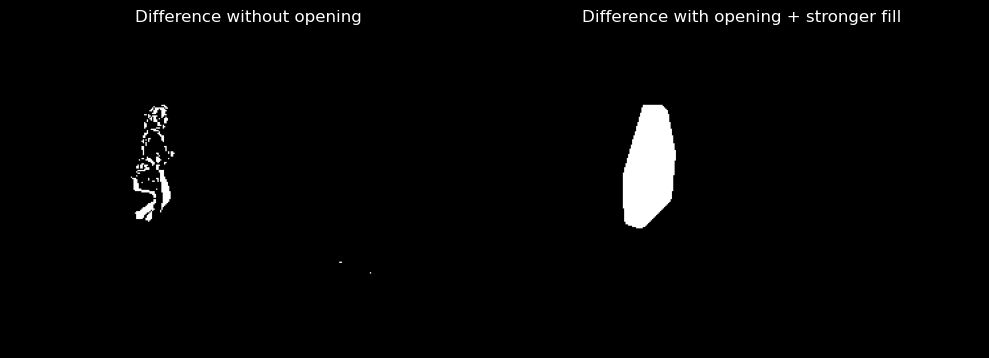

In [85]:
def show_diff(
    img1,
    img2,
    ax=None,
    with_opening=False,
    fill_regions=False,
    min_area=80,
    dilate_ksize=10,
    close_ksize=12,
    dilate_iter=1,
    close_iter=2,
    use_convex_hull=True,
    ):
    diff = cv2.absdiff(img1, img2)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    (T, thresh) = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    if with_opening:
        open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, open_kernel)

    if fill_regions:
        dilate_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (dilate_ksize, dilate_ksize)
        )
        close_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (close_ksize, close_ksize)
        )
        grown = cv2.dilate(thresh, dilate_kernel, iterations=dilate_iter)
        closed = cv2.morphologyEx(grown, cv2.MORPH_CLOSE, close_kernel, iterations=close_iter)

        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        filled = np.zeros_like(closed)
        for cnt in contours:
            if cv2.contourArea(cnt) < min_area:
                continue
            if use_convex_hull:
                cnt = cv2.convexHull(cnt)
            cv2.drawContours(filled, [cnt], -1, 255, thickness=cv2.FILLED)

        thresh = filled

    if ax is not None:
        ax.imshow(thresh, cmap="gray")
        ax.axis("off")

    return T, thresh

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title("Difference without opening")
T_no_open, _ = show_diff(img1, img2, ax[0], with_opening=False, fill_regions=False)

ax[1].set_title("Difference with opening + stronger fill")
T_open, _ = show_diff(img1, img2, ax[1], with_opening=True, fill_regions=True)

print(f"Otsu threshold without opening: {T_no_open}")
print(f"Otsu threshold with opening + stronger fill: {T_open}")
plt.tight_layout()
plt.show()

array([[    0,     0,   360,   240, 86041],
       [  108,    59,     4,     5,    11],
       [  113,    59,     5,     7,    20],
       [  108,    67,     3,     3,     5],
       [  116,    66,     3,     4,     8],
       [  121,    92,     3,     3,     5],
       [  103,    97,     6,     5,    14],
       [  110,    96,     4,     5,    12],
       [  112,   106,     9,    28,   131],
       [   93,   112,     5,    10,    34],
       [  106,   122,     4,     4,     8],
       [   94,   129,    16,    16,   111]], dtype=int32)

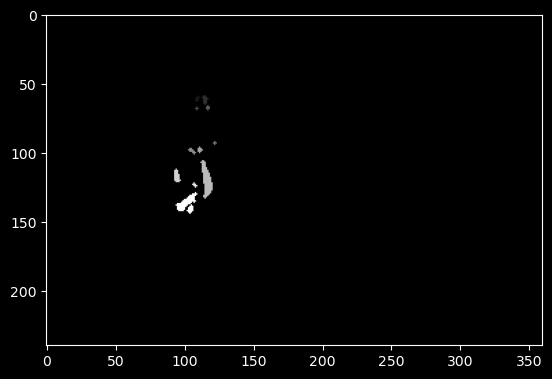

In [86]:

_, thresh = show_diff(img1, img2, with_opening=True)

retval, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)

plt.imshow((labels / retval) * 255, cmap="gray")

stats

Largest component index: 8
Largest component area: 131


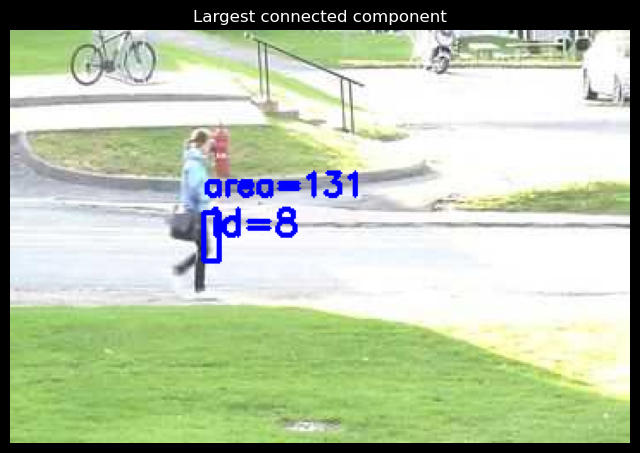

In [87]:
# Wizualizacja największego obiektu z connectedComponentsWithStats
I_VIS = img1.copy()  # kopia obrazu wejściowego

if stats.shape[0] > 1:  # czy istnieją obiekty poza tłem
    pi = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    x = stats[pi, cv2.CC_STAT_LEFT]
    y = stats[pi, cv2.CC_STAT_TOP]
    w = stats[pi, cv2.CC_STAT_WIDTH]
    h = stats[pi, cv2.CC_STAT_HEIGHT]
    area = stats[pi, cv2.CC_STAT_AREA]

    # Bounding box
    cv2.rectangle(I_VIS, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Pole obiektu
    cv2.putText(
        I_VIS, f"area={area}", (x, max(0, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2
    )

    # Indeks obiektu przy centroidzie
    cx, cy = centroids[pi].astype(int)
    cv2.putText(
        I_VIS, f"id={pi}", (cx, cy),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2
    )

    print(f"Largest component index: {pi}")
    print(f"Largest component area: {area}")
else:
    print("No foreground objects detected.")

# cv2 rysuje w BGR, a matplotlib oczekuje RGB
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(I_VIS, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Largest connected component")
plt.show()

In [88]:
def evaluate_binary_mask(pred_mask, gt_mask, ignore_gt_values=(50, 85, 170)):
    # Convert to single channel if needed
    if pred_mask.ndim == 3:
        pred_mask = cv2.cvtColor(pred_mask, cv2.COLOR_BGR2GRAY)
    if gt_mask.ndim == 3:
        gt_mask = cv2.cvtColor(gt_mask, cv2.COLOR_BGR2GRAY)

    # Build validity mask: ignore uncertain GT labels
    valid = np.ones_like(gt_mask, dtype=bool)
    for v in ignore_gt_values:
        valid &= (gt_mask != v)

    # Binarize prediction and GT
    pred_fg = (pred_mask == 255)
    gt_fg = (gt_mask == 255)

    # Apply valid-mask filtering
    pred_fg = pred_fg[valid]
    gt_fg = gt_fg[valid]

    tp = int(np.sum(pred_fg & gt_fg))
    fp = int(np.sum(pred_fg & (~gt_fg)))
    tn = int(np.sum((~pred_fg) & (~gt_fg)))
    fn = int(np.sum((~pred_fg) & gt_fg))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# Example usage with your current pipeline
_, pred_mask = show_diff(img1, img2, with_opening=True)
metrics = evaluate_binary_mask(pred_mask, ground_truth)
metrics

{'TN': 83345,
 'FP': 37,
 'FN': 903,
 'TP': 157,
 'precision': 0.8092783505154639,
 'recall': 0.1481132075471698,
 'f1': 0.25039872408293457}

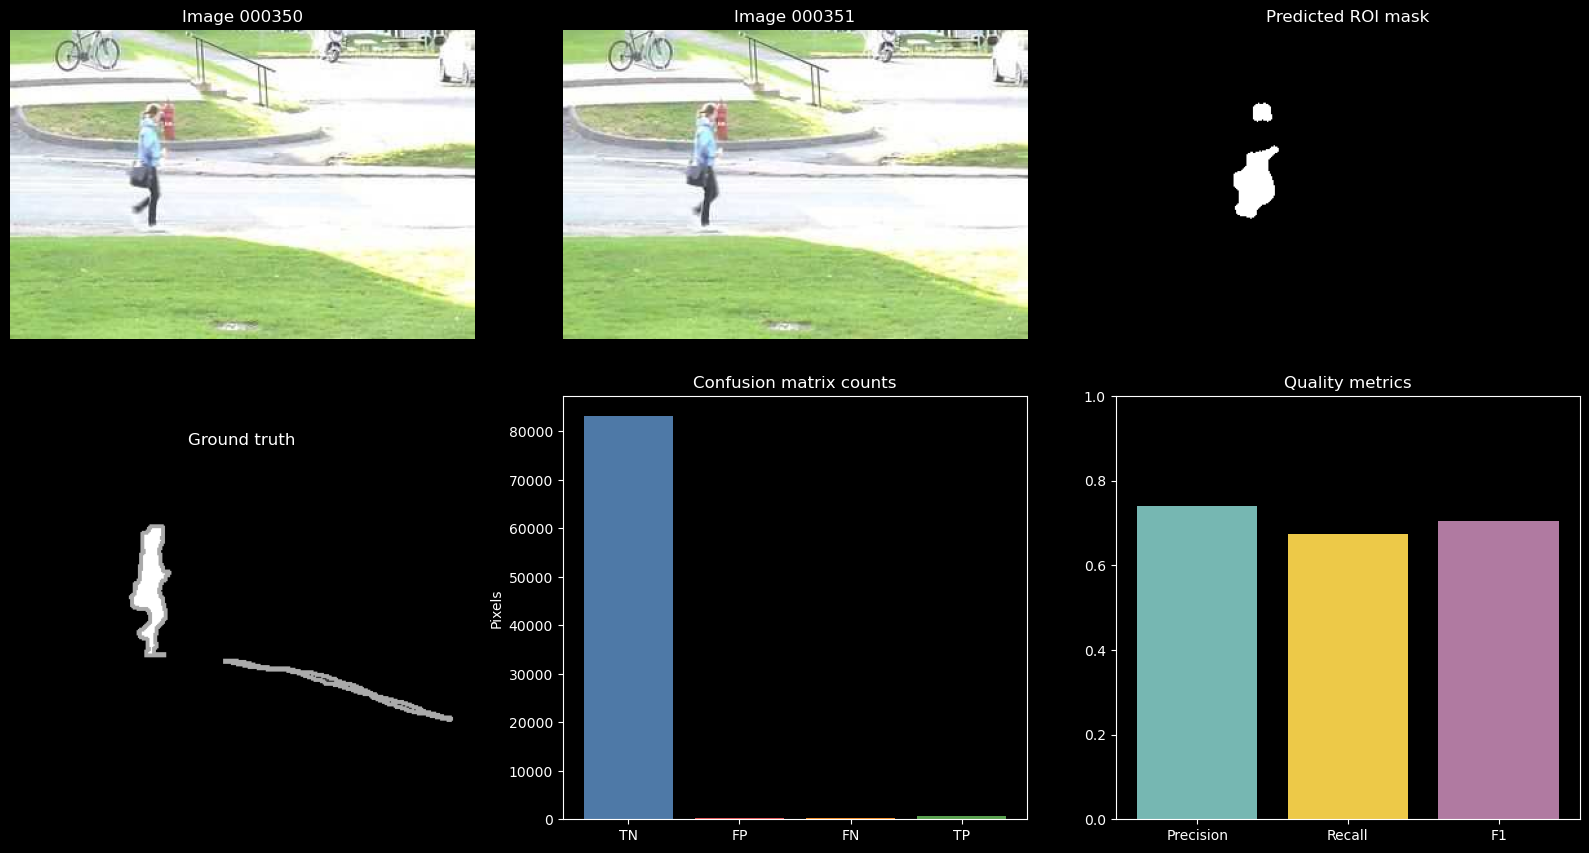

Frame pair: 000350 -> 000351
TN=83132, FP=250, FN=347, TP=713 | P=0.7404, R=0.6726, F1=0.7049


{'TN': 83132,
 'FP': 250,
 'FN': 347,
 'TP': 713,
 'precision': 0.7403946002076843,
 'recall': 0.6726415094339623,
 'f1': 0.7048937221947602}

In [89]:
def evaluate_frame(
    index,
    input_dir=pedestrinan_input_dir,
    step=1,
    with_opening=True,
    fill_regions=True,
    **diff_kwargs,
    ):
    """
    Load frame pair (index, index+step), compute ROI mask, evaluate against GT,
    and visualize images + metrics.
    
    Extra keyword args are passed to show_diff (e.g. dilate_ksize, close_ksize,
    min_area, use_convex_hull).
    """
    img1, img2, gt = load_2_images(input_dir, from_idx=index, skip=step)
    _, pred_mask = show_diff(
        img1,
        img2,
        with_opening=with_opening,
        fill_regions=fill_regions,
        **diff_kwargs,
    )
    m = evaluate_binary_mask(pred_mask, gt)

    # Visualization: img1, img2, prediction, GT, and metrics
    fig, ax = plt.subplots(2, 3, figsize=(16, 9))

    ax[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    ax[0, 0].set_title(f"Image {index:06d}")
    ax[0, 0].axis("off")

    ax[0, 1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    ax[0, 1].set_title(f"Image {index + step:06d}")
    ax[0, 1].axis("off")

    ax[0, 2].imshow(pred_mask, cmap="gray")
    ax[0, 2].set_title("Predicted ROI mask")
    ax[0, 2].axis("off")

    gt_gray = cv2.cvtColor(gt, cv2.COLOR_BGR2GRAY) if gt.ndim == 3 else gt
    ax[1, 0].imshow(gt_gray, cmap="gray")
    ax[1, 0].set_title("Ground truth")
    ax[1, 0].axis("off")

    # Confusion counts
    labels = ["TN", "FP", "FN", "TP"]
    values = [m["TN"], m["FP"], m["FN"], m["TP"]]
    ax[1, 1].bar(labels, values, color=["#4E79A7", "#E15759", "#F28E2B", "#59A14F"] )
    ax[1, 1].set_title("Confusion matrix counts")
    ax[1, 1].set_ylabel("Pixels")

    # Precision / Recall / F1
    prf_labels = ["Precision", "Recall", "F1"]
    prf_values = [m["precision"], m["recall"], m["f1"]]
    ax[1, 2].bar(prf_labels, prf_values, color=["#76B7B2", "#EDC948", "#B07AA1"] )
    ax[1, 2].set_ylim(0, 1)
    ax[1, 2].set_title("Quality metrics")

    plt.tight_layout()
    plt.show()

    print(f"Frame pair: {index:06d} -> {index + step:06d}")
    print(
        f"TN={m['TN']}, FP={m['FP']}, FN={m['FN']}, TP={m['TP']} | "
        f"P={m['precision']:.4f}, R={m['recall']:.4f}, F1={m['f1']:.4f}"
    )

    return m


# Example call (less aggressive fill than defaults in show_diff)
frame_metrics = evaluate_frame(
    index=idx,
    step=1,
    with_opening=True,
    fill_regions=True,
    use_convex_hull=False,
    dilate_ksize=5,
    close_ksize=11,
    min_area=50,
    )
frame_metrics